# Customer Segmentation — 03: DBSCAN

**Series:** 01 EDA & RFM → 02 KMeans → 03 DBSCAN (this notebook) → 04 PCA & t-SNE.

KMeans *partitions*; DBSCAN *discovers* — it only reports clusters where density
demands them, and everything else becomes noise. Notebook 01 predicted the RFM cloud
is one continuous density; this notebook tests that prediction honestly:

1. `min_samples` choice and the **k-distance graph** for selecting `eps`
2. An `eps` grid — from over-smoothing (one blob) to fragmentation (micro-clusters)
3. The working solution: silhouette (noise excluded) + **knife plot**
4. Noise analysis — who DBSCAN refuses to cluster, and why that is the useful output
5. KMeans vs DBSCAN comparison

## 1. Setup, data, shared preprocessing (identical to notebooks 01–02)

In [1]:
import os
import shutil
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
RANDOM_STATE = 42

DATA_PATH = "data/online_retail.csv"
KAGGLE_DATASET = "vijayuv/onlineretail"
MIRROR_URL = (
    "https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/"
    "master/data/retail-data/all/online-retail-dataset.csv"
)


def fetch_data(path: str = DATA_PATH) -> str:
    """Download the dataset from Kaggle, falling back to a GitHub mirror."""
    if os.path.exists(path):
        print(f"Found cached file: {path}")
        return path
    os.makedirs(os.path.dirname(path), exist_ok=True)
    try:
        import kagglehub  # pip install kagglehub

        download_dir = kagglehub.dataset_download(KAGGLE_DATASET)
        csv_files = [f for f in os.listdir(download_dir) if f.endswith(".csv")]
        shutil.copy(os.path.join(download_dir, csv_files[0]), path)
        print(f"Downloaded from Kaggle: {KAGGLE_DATASET}")
    except Exception as exc:
        print(f"Kaggle download failed ({exc!r}), using GitHub mirror.")
        urllib.request.urlretrieve(MIRROR_URL, path)
        print("Downloaded from mirror.")
    return path


def build_rfm(path: str = DATA_PATH) -> pd.DataFrame:
    """Cleaning rules and RFM+ construction — identical to notebook 01."""
    df = pd.read_csv(path, encoding="ISO-8859-1")
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
    canc = df.InvoiceNo.astype(str).str.startswith("C")
    d = df[~canc & df.CustomerID.notnull() & (df.Quantity > 0) & (df.UnitPrice > 0)].copy()
    d["Revenue"] = d.Quantity * d.UnitPrice
    snapshot = d.InvoiceDate.max() + pd.Timedelta(days=1)
    rfm = d.groupby("CustomerID").agg(
        recency=("InvoiceDate", lambda s: (snapshot - s.max()).days),
        frequency=("InvoiceNo", "nunique"),
        monetary=("Revenue", "sum"),
        tenure=("InvoiceDate", lambda s: (snapshot - s.min()).days),
        n_products=("StockCode", "nunique"),
    )
    rfm["avg_order_value"] = rfm.monetary / rfm.frequency
    return rfm


from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

rfm = build_rfm(fetch_data())
X = StandardScaler().fit_transform(np.log1p(rfm))
print(f"Feature matrix: {X.shape[0]:,} customers × {X.shape[1]} log-scaled features")

Found cached file: data/online_retail.csv
Feature matrix: 4,338 customers × 6 log-scaled features


## 2. Parameters: `min_samples` and the k-distance graph

`min_samples` sets how many neighbors make a point "core"; a common rule of thumb is
≥ dimensionality + 1, made stricter for noisy data — we use **10** (2,000+ customers
per percent of the base, so a 10-customer micro-group is not a segment).

`eps` comes from the **k-distance graph**: sort every customer's distance to its
`min_samples`-th neighbor; the elbow — where the curve turns from flat to steep —
marks the density boundary between "inside the cloud" and "outlier territory".

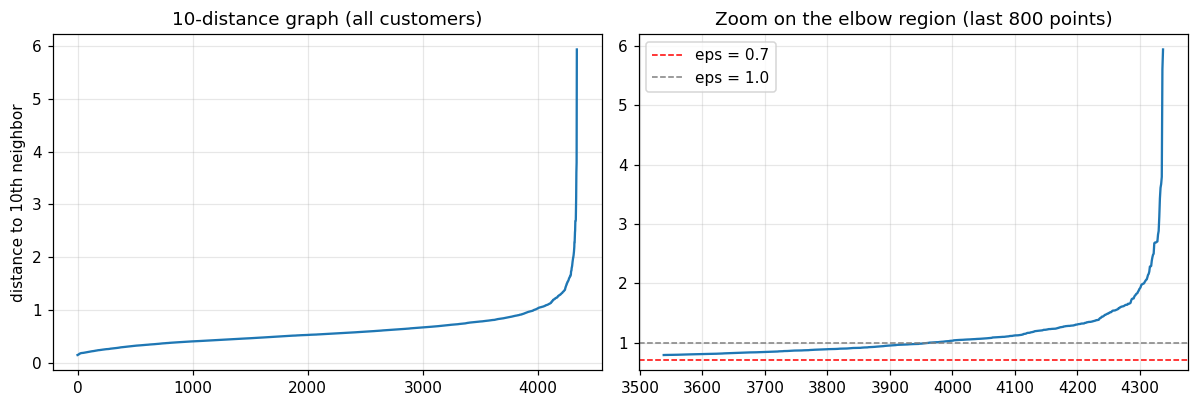

k-distance percentiles: {50: 0.543, 75: 0.719, 90: 0.953, 95: 1.162, 99: 1.812}


In [2]:
MIN_SAMPLES = 10
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X)
distances, _ = nn.kneighbors(X)
kdist = np.sort(distances[:, -1])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(kdist)
axes[0].set_title(f"{MIN_SAMPLES}-distance graph (all customers)")
axes[0].set_ylabel("distance to 10th neighbor")

axes[1].plot(np.arange(len(kdist))[-800:], kdist[-800:])
for e, c in [(0.7, "red"), (1.0, "gray")]:
    axes[1].axhline(e, ls="--", c=c, lw=1, label=f"eps = {e}")
axes[1].set_title("Zoom on the elbow region (last 800 points)")
axes[1].legend()
plt.tight_layout()
plt.show()
print("k-distance percentiles:",
      {p: round(float(np.percentile(kdist, p)), 3) for p in [50, 75, 90, 95, 99]})

The curve bends in the ~0.9–1.1 range (the classic elbow read) — but on a continuous
density an elbow-chosen eps risks swallowing everything into one cluster. Rather than
trusting a single read, we scan `eps` across the plausible range and let the outcomes
speak.

## 3. The eps grid — over-smoothing to fragmentation

In [3]:
rows = []
for eps in [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2]:
    labels = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit(X).labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = float((labels == -1).mean())
    mask = labels != -1
    sil = (silhouette_score(X[mask], labels[mask])
           if n_clusters > 1 else np.nan)
    rows.append({"eps": eps, "clusters": n_clusters,
                 "noise_share": round(noise, 3),
                 "silhouette_excl_noise": round(sil, 3) if sil == sil else None})
print(pd.DataFrame(rows).to_string(index=False))

 eps  clusters  noise_share  silhouette_excl_noise
 0.4        13        0.639                 -0.095
 0.5        10        0.409                 -0.120
 0.6         3        0.240                  0.200
 0.7         2        0.139                  0.274
 0.8         1        0.087                    NaN
 0.9         1        0.050                    NaN
 1.0         1        0.034                    NaN
 1.2         1        0.016                    NaN


The table tells one story with two failure ends:

- **eps ≥ 0.8 — over-smoothing:** a single cluster plus a shrinking noise rim. The
  elbow-suggested value (~1.0) lands here: the RFM cloud really is one connected
  density at that resolution.
- **eps ≤ 0.5 — fragmentation:** 10–13 micro-clusters, 40–75% noise, *negative*
  silhouettes — dust, not structure.
- **eps = 0.7 — the only genuinely multi-modal reading:** two clusters of comparable
  mass, ~14% noise, silhouette 0.27. This is the working solution we audit below.

In [4]:
EPS_FINAL = 0.7
dbscan = DBSCAN(eps=EPS_FINAL, min_samples=MIN_SAMPLES).fit(X)
labels = dbscan.labels_
rfm["dbscan"] = labels
n_clusters = len(set(labels)) - 1
mask = labels != -1
avg = silhouette_score(X[mask], labels[mask])
print(f"eps={EPS_FINAL}: {n_clusters} clusters, noise {np.mean(labels == -1):.1%}, "
      f"silhouette (excl. noise) {avg:.3f}")
print("cluster sizes:", np.bincount(labels[mask]))

eps=0.7: 2 clusters, noise 13.9%, silhouette (excl. noise) 0.274
cluster sizes: [2368 1368]


## 4. Silhouette knife plot (noise excluded)

Same audit as in notebook 02: every blade should cross the red average line, and blade
thicknesses should be of comparable order. Noise points have no cluster, so they are
excluded by construction — the plot judges only what DBSCAN *claims* to be clusters.

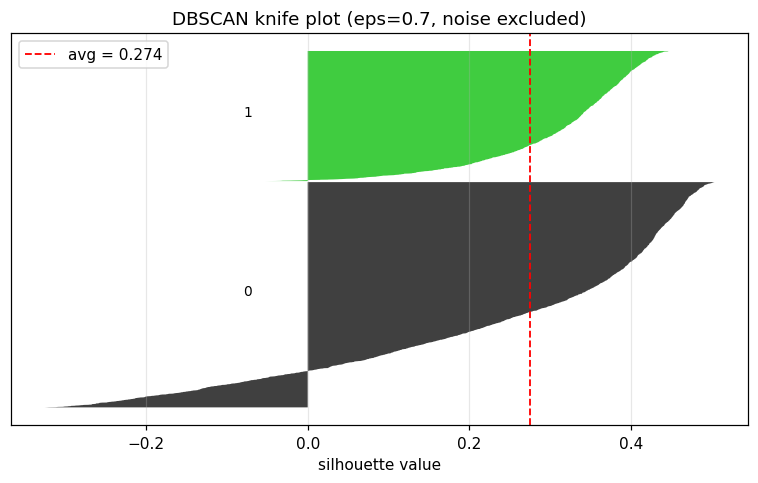

In [5]:
samp = silhouette_samples(X[mask], labels[mask])
fig, ax = plt.subplots(figsize=(7, 4.5))
y_lower = 10
for i in range(n_clusters):
    vals = np.sort(samp[labels[mask] == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=cm.nipy_spectral(float(i) / max(n_clusters, 2)), alpha=0.75)
    ax.text(-0.08, y_lower + 0.5 * len(vals), str(i), fontsize=9)
    y_lower = y_upper + 10
ax.axvline(avg, color="red", ls="--", lw=1.2, label=f"avg = {avg:.3f}")
ax.set_xlabel("silhouette value")
ax.set_yticks([])
ax.set_title(f"DBSCAN knife plot (eps={EPS_FINAL}, noise excluded)")
ax.legend()
plt.tight_layout()
plt.show()

Both blades cross the line with comparable thickness — as a two-cluster solution it is
internally healthy. But note what it is: essentially the engaged/disengaged split that
KMeans found at k=2, discovered a second way.

## 5. Noise analysis — DBSCAN's real contribution here

Noise customers: 602 (13.9%)
                 noise_median  core_median
recency                  14.0         58.0
frequency                 3.0          2.0
monetary               1182.0        640.3
tenure                  159.0        255.0
n_products               26.0         37.0
avg_order_value         334.7        289.7

Revenue held by noise customers: 46.8% of total
Top-5 noise customers by monetary:
            recency  frequency  monetary
CustomerID                              
14646.0           2         73  280206.0
18102.0           1         60  259657.0
17450.0           8         46  194551.0
16446.0           1          2  168472.0
14911.0           1        201  143825.0


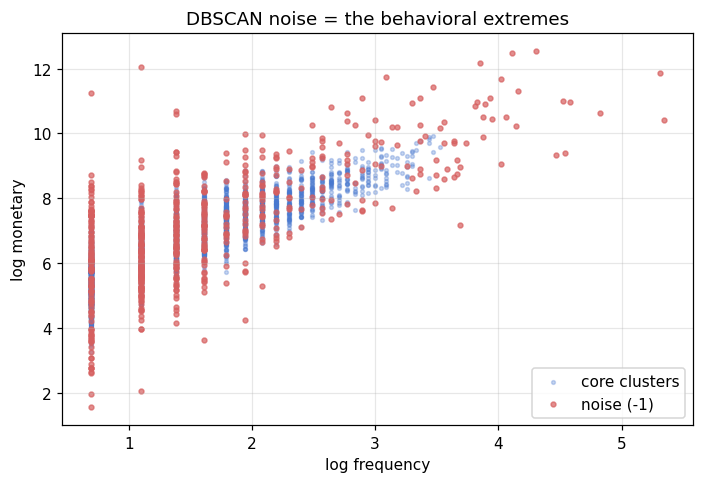

In [6]:
noise_df = rfm[rfm.dbscan == -1]
core_df = rfm[rfm.dbscan != -1]
summary = pd.DataFrame({
    "noise_median": noise_df.median(numeric_only=True),
    "core_median": core_df.median(numeric_only=True),
}).loc[["recency", "frequency", "monetary", "tenure", "n_products", "avg_order_value"]]
print(f"Noise customers: {len(noise_df)} ({len(noise_df) / len(rfm):.1%})")
print(summary.round(1).to_string())
print(f"\nRevenue held by noise customers: "
      f"{noise_df.monetary.sum() / rfm.monetary.sum():.1%} of total")
print("Top-5 noise customers by monetary:")
print(noise_df.nlargest(5, "monetary")[["recency", "frequency", "monetary"]].round(0).to_string())

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(np.log1p(core_df.frequency), np.log1p(core_df.monetary),
           s=6, alpha=0.3, c="#4878CF", label="core clusters")
ax.scatter(np.log1p(noise_df.frequency), np.log1p(noise_df.monetary),
           s=10, alpha=0.7, c="#D65F5F", label="noise (-1)")
ax.set_xlabel("log frequency")
ax.set_ylabel("log monetary")
ax.set_title("DBSCAN noise = the behavioral extremes")
ax.legend()
plt.tight_layout()
plt.show()

The noise set is **not** a rag-bag of odd small accounts — it is the
high-value rim. Noise customers are *more* recent (median 14 vs 58 days), *more*
frequent (3 vs 2 orders) and spend nearly twice as much (€1,182 vs €640) than clustered
customers, and they include every whale in the book (top five: €280k, €260k, €195k,
€168k, €144k). The headline number: **13.9% of customers classified as "noise" hold
46.8% of total revenue.**

That inverts the usual reading of DBSCAN output. These are not points to discard — they
are the accounts too behaviorally extreme for any segment average to describe, which is
exactly the definition of a key-account list. A density algorithm, asked only "where is
the mass?", has produced a defensible, parameter-driven answer to "who needs individual
handling?".

In [7]:
km3 = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit(X)
comp = pd.DataFrame({
    "KMeans (k=3)": {"clusters": 3, "noise": "0%",
                     "silhouette": round(silhouette_score(X, km3.labels_), 3),
                     "smallest cluster": int(np.bincount(km3.labels_).min())},
    f"DBSCAN (eps={EPS_FINAL})": {"clusters": n_clusters,
                                  "noise": f"{np.mean(labels == -1):.1%}",
                                  "silhouette": round(avg, 3),
                                  "smallest cluster": int(np.bincount(labels[mask]).min())},
}).T
print(comp.to_string())

                 clusters  noise silhouette smallest cluster
KMeans (k=3)            3     0%      0.296              977
DBSCAN (eps=0.7)        2  13.9%      0.274             1368


**Conclusion.** On this data the two algorithms answer different questions, and both
answers are useful:

- **KMeans** partitions the continuum into actionable tiers (notebook 02's three
  segments carrying the 39%-of-customers / 86%-of-revenue finding). Its "clusters" are
  management constructs, and that is fine.
- **DBSCAN**, asked to find density islands, reports truthfully that there are barely
  any — at the elbow-eps everything is one cloud, and the only stable multi-cluster
  reading reproduces the coarse engaged/disengaged split at a slightly *lower*
  silhouette than KMeans achieves with three. Its unique contribution is the **noise
  set**: 602 customers holding 46.8% of revenue, identified without a single
  hand-set revenue threshold.

A method reporting "no structure of my kind here" is information, not failure — the
mistake would be forcing micro-cluster dust into a segmentation deck. The productive
combination is KMeans for the tiers, DBSCAN's noise flag for the accounts that should
never be treated as part of a tier.

**Next:** notebook 04 — PCA loadings and t-SNE maps, with both labelings overlaid.